In [1]:
from pathlib import Path
from pprint import pprint

import numpy as np
import optitrack
import spikeinterface.full as si

In [2]:
# Set global arguments for parallel processing
global_job_kwargs = dict(n_jobs=8, chunk_duration="1s", progress_bar=True)
si.set_global_job_kwargs(**global_job_kwargs)

# Set directories
project_dir = Path(r"(Y:\physiology\5800941\kilosort_260831)")
phys_path = project_dir
ks_path = project_dir / "kilosort4"
spikes_path = project_dir / "analyzer.zarr"

# OptiTrack take (CSV export + top-down video) synced to the recording above
optitrack_csv_path = project_dir / "optitrack/Take 2026-08-20 02.17.58 PM.csv"
optitrack_video_path = (
        project_dir / "optitrack/Take 2026-08-20 02.17.58 PM-Camera 6 (577611).avi"
)

# Recording format: True for Open Ephys, False for SpikeGLX
is_open_ephys = True

# Open Ephys: stream to read (only used if is_open_ephys is True)
oe_stream_name = "Record Node 101#OneBox-100.ProbeA"
oe_event_name = "Record Node 101#OneBox-100.OneBox-ADC"
oe_adc_id = "ADC0"

# SpikeGLX: stream id to read, e.g. "imec0.ap" (only used if is_open_ephys is False)
spikeglx_stream_id = "imec0.ap"
spikeglx_event_id = "obx0"
spikeglx_adc_id = "obx0#XA0"

In [3]:
# Run if you want to automate w/ a dict
analysis_protocol = {
    "preprocessing": {
        "bandpass_filter": {},
        "common_reference": {"operator": "average"},
        "detect_and_remove_bad_channels": {},
    },
    "sorting": {"sorter_name": "kilosort4", "verbose": True},
    "postprocessing": {
        "random_spikes": {},
        "noise_levels": {},
        "templates": {},
        "unit_locations": {"method": "center_of_mass"},
        "amplitude_scalings": {},
        "spike_amplitudes": {},
        "spike_locations": {},
        "waveforms": {},
        "template_similarity": {},
        "correlograms": {},
        "auto_correlograms": {},
        "isi_histograms": {},
        "principal_components": {},
        "valid_unit_periods": {},
        "quality_metrics": {},
        # Not "spiketrain_metrics": it only computes num_spikes/firing_rate,
        # which quality_metrics already computes from the same underlying
        # functions. Computing both makes get_metrics_extension_data() (used
        # by bombcell_label_units) produce duplicate columns, and loading a
        # saved spiketrain_metrics extension hits a spikeinterface 0.104.8 bug
        # (NotImplementedError from an unimplemented backward-compat handler).
        "template_metrics": {"include_multi_channel_metrics": True},
    },
}

In [4]:
# 1. Load recording
if is_open_ephys:
    recording = si.read_openephys(folder_path=phys_path, stream_name=oe_stream_name, load_sync_timestamps=True)
    events_raw = si.read_openephys(folder_path=phys_path, stream_name=oe_event_name, load_sync_timestamps=True)
else:
    recording = si.read_spikeglx(folder_path=phys_path, stream_id=spikeglx_stream_id)
    events_raw = si.read_spikeglx(folder_path=phys_path, stream_id=spikeglx_event_id)

# Extract some basic info
probe = recording.get_probe()
channel_ids = recording.get_channel_ids()
fs = recording.get_sampling_frequency()
num_chan = recording.get_num_channels()
num_seg = recording.get_num_segments()
num_samples = recording.get_num_samples()
ts = recording.get_times()
event_ts = events_raw.get_times()

In [5]:
# 2. Check whether kilosort4 has already been run into ks_path
ks_output_exists = (ks_path / "spike_times.npy").exists()
print(
    f"Found existing kilosort4 output in {ks_path}, will load it."
    if ks_output_exists
    else f"No kilosort4 output found in {ks_path}, spike sorting will be run."
)

if not ks_output_exists:
    # Preprocess and run spike sorting, saving kilosort4's output to ks_path
    recording_preprocessed = si.apply_preprocessing_pipeline(
        recording, analysis_protocol["preprocessing"]
    )
    analysis_protocol["sorting"]["sorter_params"] = si.get_default_sorter_params(
        sorter_name_or_class=analysis_protocol["sorting"]["sorter_name"]
    )
    sorting = si.run_sorter(
        recording=recording_preprocessed, folder=ks_path, **analysis_protocol["sorting"]
    )
    recording_for_analysis = recording_preprocessed
else:
    # Load the existing kilosort4 output
    sorting = si.read_kilosort(ks_path)

    # kilosort4 drops its own "bad" channels internally, so its output may have
    # fewer channels than the full recording. channel_map.npy tells us which of
    # the original recording channels were kept and in what order, so the
    # recording used for the analyzer matches what kilosort4 actually sorted.
    channel_map = np.load(ks_path / "channel_map.npy")
    recording_for_analysis = recording.select_channels(
        channel_ids=recording.channel_ids[channel_map]
    )
    ks_labels = sorting._properties["KSLabel"]

Found existing kilosort4 output in C:\Working\session0\2026-08-20_14-17-52\kilosort, will load it.


In [6]:
# 3. Load the sorting analyzer if it was already saved to spikes_path, otherwise
# create it, compute all the listed extensions, and save it there
if spikes_path.exists():
    # spikeinterface 0.104.8's spiketrain_metrics load bug (see analysis_protocol
    # above) triggers unconditionally on load, so a "spiketrain_metrics"
    # extension saved by an earlier run of this notebook can never be loaded
    # normally again. Purge it directly from the zarr store first, bypassing
    # the broken load path, then load the analyzer as usual.
    import zarr

    zarr_root = zarr.open(str(spikes_path), mode="r+")
    if (
            "extensions" in zarr_root.keys()
            and "spiketrain_metrics" in zarr_root["extensions"].keys()
    ):
        del zarr_root["extensions"]["spiketrain_metrics"]
        zarr.consolidate_metadata(zarr_root.store)

    analyzer = si.load_sorting_analyzer(spikes_path)
    print(f"Loaded existing sorting analyzer from {spikes_path}")
else:
    analyzer = si.create_sorting_analyzer(
        recording=recording_for_analysis,
        sorting=sorting,
        folder=spikes_path,
        format="zarr",
    )
    analyzer.compute(analysis_protocol["postprocessing"])
    print(f"Created and saved new sorting analyzer to {spikes_path}")

Loaded existing sorting analyzer from C:\Working\session0\2026-08-20_14-17-52\spikes.zarr


In [7]:
# 3.5 Check the results of sorting visually
# Can also use si.plot_unit_summary() to view individual units

# sig.run_mainwindow(analyzer=analyzer, mode="desktop")

In [8]:
# Automatically label units
bombcell_labels = si.bombcell_label_units(sorting_analyzer=analyzer)
print(
    f"Bombcell results: 'good' units: {sum(bombcell_labels["bombcell_label"] == 'good')}, 'noise' units: {sum(bombcell_labels["bombcell_label"] == 'noise')}")

Bombcell results: 'good' units: 0, 'noise' units: 381


In [9]:
# 4. Extract OptiTrack shutter-closure timestamps from the ADC0 TTL
# TTL is high (+5V) while the shutter is open/exposing and falls to 0V when the
# shutter closes and the frame is acquired -> we want the falling edges.
if is_open_ephys:
    adc_channel = oe_adc_id
else:
    adc_channel = spikeglx_adc_id

shutter_close_times = optitrack.extract_shutter_close_times(
    events_raw, channel_id=adc_channel
)

print(f"Detected {len(shutter_close_times)} shutter-closure events")
if len(shutter_close_times) > 1:
    isis = np.diff(shutter_close_times)
    print(
        f"Inter-frame interval: {isis.mean() * 1000:.3f} +/- {isis.std() * 1000:.3f} ms "
        f"({1 / isis.mean():.2f} Hz), range [{isis.min() * 1000:.3f}, {isis.max() * 1000:.3f}] ms"
    )

Detected 432235 shutter-closure events
Inter-frame interval: 8.333 +/- 0.016 ms (120.00 Hz), range [8.317, 8.350] ms


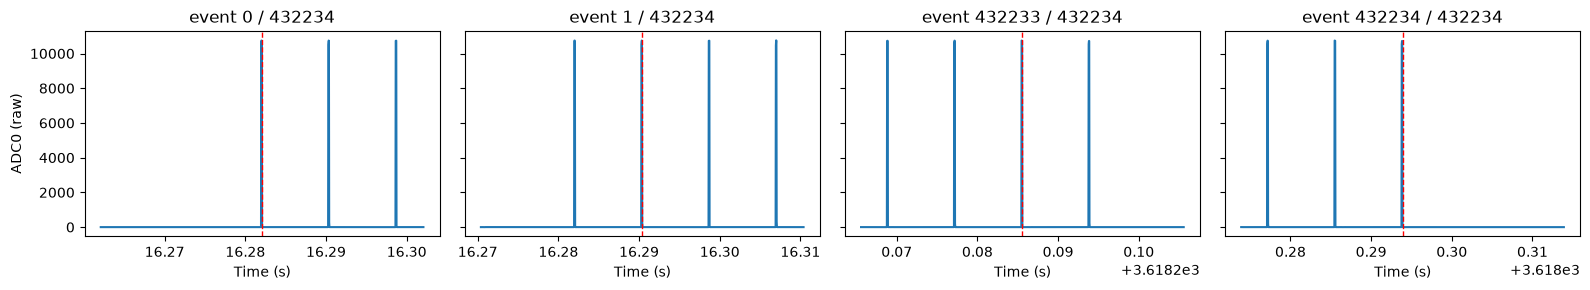

In [10]:
# 4.5 Sanity check: does the falling-edge detection hold up across the whole
# recording, not just wherever a single eyeballed time window happened to land?
%matplotlib inline
fig = optitrack.plot_shutter_close_sanity_check(events_raw, shutter_close_times, channel_id=adc_channel)

In [11]:
# 4.6 Save the shutter-closure timestamps (seconds, relative to the recording's own time base)
shutter_times_path = optitrack.save_shutter_close_times(
    shutter_close_times, phys_path.parent / "optitrack_shutter_close_times.npy"
)
print(f"Saved {len(shutter_close_times)} timestamps to {shutter_times_path}")

Saved 432235 timestamps to C:\Working\session0\2026-08-20_14-17-52\Record Node 101\experiment1\optitrack_shutter_close_times.npy


In [12]:
# 4.7 Cross-check against the OptiTrack CSV export (ground-truth frame count)
sync_stats = optitrack.cross_check_with_optitrack_csv(
    shutter_close_times, optitrack_csv_path
)
pprint(sync_stats)

{'frame_count_difference': 1,
 'irregular_interval_indices': array([], dtype=int64),
 'n_detected': 432235,
 'n_intervals': 432234,
 'n_regular_intervals': 432234,
 'optitrack_frame_rate': 120.0,
 'optitrack_total_frames': 432236}


In [13]:
# 5. Load the OptiTrack take and align its frames 1:1 with shutter_close_times
take = optitrack.load_optitrack_csv(optitrack_csv_path)
frame_indices = optitrack.align_frames_to_shutter_events(shutter_close_times, take)

rigid_body_name = "Headset"
rigid_body = take.rigid_bodies[rigid_body_name]
aligned_rotation_xyzw = rigid_body.rotation_xyzw[frame_indices]
aligned_position = rigid_body.position[frame_indices]

print(f"Rigid bodies in take: {list(take.rigid_bodies)}")
print(
    f"Aligned {len(frame_indices)} frames to {len(shutter_close_times)} shutter-closure events"
)

Rigid bodies in take: ['Headset']
Aligned 432235 frames to 432235 shutter-closure events


In [14]:
# 5.5 Calibrate the head frame, then heading and kinematics for the aligned frames
# The rigid body's local axes are just the *world* axes frozen at the moment the
# body was created in Motive, so they carry no anatomical meaning and the nose
# axis has to be recovered from the data (see optitrack/heading.py). Calibrate on
# the whole take rather than the shutter-aligned subset -- more running frames,
# and the head frame is a property of the rigid body, not of the ephys sync.
head_frame = optitrack.calibrate_head_frame(
    rigid_body.rotation_xyzw, rigid_body.position, take.times
)
print(head_frame)

heading_deg = optitrack.compute_heading(
    aligned_rotation_xyzw, head_frame, flip_direction=True
)
kinematics = optitrack.compute_kinematics(aligned_position, shutter_close_times)

# Heading for *every* take frame (not just the ones aligned to shutter_close_times),
# indexed the same way as the raw video -- this is what the heading-video widget uses.
heading_deg_full = optitrack.compute_heading(
    rigid_body.rotation_xyzw, head_frame, flip_direction=True
)

# Heading is an azimuth on the floor, so it degrades as the nose approaches
# vertical. Rare here, but worth knowing the rate before trusting a tuning curve.
elevation_deg = optitrack.compute_head_elevation(aligned_rotation_xyzw, head_frame)

print(f"Heading range: [{heading_deg.min():.1f}, {heading_deg.max():.1f}] deg")
print(
    f"Nose within 10 deg of vertical (heading ill-conditioned) in "
    f"{(np.abs(elevation_deg) > 80).mean() * 100:.2f}% of frames"
)
print(
    f"Speed: mean {kinematics['speed'].mean():.1f} mm/s, max {kinematics['speed'].max():.1f} mm/s"
)

HeadFrame(forward=[+0.4340 -0.0840 -0.8970], left=[-0.8965 +0.0579 -0.4392], up=[+0.0888 +0.9948 -0.0502])
  calibrated on 32081 running frames; heading-vs-travel concentration R=0.628, residual +1.52 deg
Heading range: [0.0, 360.0] deg
Nose within 10 deg of vertical (heading ill-conditioned) in 0.90% of frames
Speed: mean 70.6 mm/s, max 1640.1 mm/s


In [15]:
# 6. Head-direction tuning curves for the "good" units (skip noise/mua/non_soma)
good_unit_ids = np.flatnonzero(ks_labels == "good")
tuning_curves = optitrack.compute_all_units_tuning_curves(
    analyzer, heading_deg, shutter_close_times, unit_ids=good_unit_ids
)
print(f"Computed tuning curves for {len(tuning_curves)}/{len(ks_labels)} units")

Computed tuning curves for 161/381 units


In [16]:
# For inline interactive figures (`%matplotlib qt` pops figures out into native
# windows instead, if you prefer that over inline widgets.)
%matplotlib qt

In [17]:
# 6.5 Scroll through each unit's tuning curve with the Left/Right arrow keys
from optitrack.widgets import show_hd_tuning_widget

unit_depths = optitrack.get_unit_depths(analyzer, unit_ids=good_unit_ids)
tuning_widget = show_hd_tuning_widget(tuning_curves, unit_depths=unit_depths)

In [18]:
# Calculate significance of tuning for each good unit
stats = optitrack.compute_hd_tuning_significance(
    analyzer, heading_deg, shutter_close_times, unit_ids=good_unit_ids
)
tuned = [u for u, s in stats.items() if s.significant]

In [19]:
tuned_dict = {k: tuning_curves[k] for k in tuned}

tuning_widget = show_hd_tuning_widget(tuned_dict, unit_depths=unit_depths)

In [ ]:
# 6.6 Step through the top-down video with Left/Right arrow keys, checking the
# computed heading (red arrow, upper-left compass) against the animal's real turns
#
# Pass heading_deg_full, not heading_deg: the widget indexes by *video* frame,
# and heading_deg is indexed by shutter event (it starts at CSV frame
# frame_indices[0], not 0). This video is Motive's own per-camera export of this
# take -- 432236 frames at 120 fps, exactly matching the CSV's frame count -- so
# video frame i is CSV frame i and frame_offset is 0.
#
# What is *not* in the CSV is how the overhead camera is mounted relative to the
# arena axes, so the compass may need rotating (compass_rotation_offset_deg) or
# mirroring (flip_direction=True in compute_heading) to line up on screen. Those
# are display conventions only; the heading itself is already fixed against the
# animal's own direction of travel.
from optitrack.widgets import show_heading_video_widget

video_widget = show_heading_video_widget(
    optitrack_video_path,
    heading_deg_full,
    take=take,
    frame_offset=0,
    compass_rotation_offset_deg=-80,
)

In [2]:
from kilosort import run_kilosort

help(run_kilosort)

Help on function run_kilosort in module kilosort.run_kilosort:

run_kilosort(
    settings,
    probe=None,
    probe_name=None,
    filename=None,
    data_dir=None,
    file_object=None,
    results_dir=None,
    data_dtype=None,
    do_CAR=True,
    invert_sign=False,
    device=None,
    progress_bar=None,
    save_extra_vars=False,
    clear_cache=False,
    save_preprocessed_copy=False,
    bad_channels=None,
    shank_idx=None,
    verbose_console=False,
    verbose_log=False,
    torch_thread_lim=None
)
    Run full spike sorting pipeline on specified data.

    Parameters
    ----------
    settings : dict
        Specifies a number of configurable parameters used throughout the
        spike sorting pipeline. See `kilosort/parameters.py` for a full list of
        available parameters.
        NOTE: `n_chan_bin` must be specified here, but all other settings are
              optional.
    probe : dict; optional.
        A Kilosort4 probe dictionary, as returned by `kilosort.